# **Hotel Revenue, Cancellations & Customer Behavior Analysis**
Даний датасет містить дані за період **2015-2017 років**. Дані представлені для двох типів готелів: **City Hotel** та **Resort Hotel**. Набір данних охоплює понад **115 тисяч записів** та містить інформації про клієнтів із близько **175 країн**.

Метою аналізу є дослідження поведінки гостей та виявлення ключових факторів, які впливають на бізнес-показники.

Проєкт спрямований на:

- аналіз поведінки гостей на всьому шляху - від бронювання номера до виселення з готелю;
- визначення факторів, які впливають на скасування бронювань;
- обчислення основних бізнес метрик,  які допомагають оцінити ефективність бізнесу;
- оцінку втрат доходу через скасування;
- аналіз сезонності бронювань.

Правильний аналіз кожного показника допоможе сформувати чітке розуміння основних бізнес-проблем. Це дасть змогу надати обгрунтовані рекомендації для покращення ефективності бізнесу та підвищення рівня утримання клієнтів.


In [1]:
# Імпорт необхідних бібліотек
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

In [2]:
# Завантажуємо дані
df = pd.read_csv('drive/MyDrive/Date_Analysis/Final_project/hotel_bookings.csv')

### **Дослідницький аналіз даних (EDA)**

In [3]:
# Розмір набору даних
print(f'Датасет містить {df.shape[0]} рядків та {df.shape[1]} колонки.')

Датасет містить 115596 рядків та 34 колонки.


In [4]:
# Перший погляд на дані
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,is_family
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,0


In [5]:
# Основна інформація про дані
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115596 entries, 0 to 115595
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           115596 non-null  object 
 1   is_canceled                     115596 non-null  int64  
 2   lead_time                       115596 non-null  int64  
 3   arrival_date_year               115596 non-null  int64  
 4   arrival_date_month              115596 non-null  object 
 5   arrival_date_week_number        115596 non-null  int64  
 6   arrival_date_day_of_month       115596 non-null  int64  
 7   stays_in_weekend_nights         115596 non-null  int64  
 8   stays_in_week_nights            115596 non-null  int64  
 9   adults                          115596 non-null  int64  
 10  children                        115592 non-null  float64
 11  babies                          115596 non-null  int64  
 12  meal            

In [6]:
# Перевіримо датасет на наявність пропущених даних
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_percent[missing_percent > 0]

,0
children,0.003460
country,0.415239
agent,13.820547
company,94.130420


Маємо пропущені значення по чотирьом колонкам:
- *children* - кількість дітей. Тобто, чи подорожує людина з дітьми, і якщо так, то вказується їх кількість. У нас дуже маленький відсоток пропущених значень в цій колонці. Я б припустила, що в цьому випадку пропущені значення означають, що людина подорожує без дітей. Тому, замінимо пропущені значення на 0.
- *country* - країна гостя. Маємо *0.4%* пропущених значень. Замінимо відсутні значення на Undefined.
- *agent* - ID туристичного агента, майже *14%* відсутніх значень. Скоріще за все, значення відсутні, тому що букінг відбувався не через агенції, відповідно заповнювати в цій колонці не було чого. Тому, замінимо відсутні значення на 0.
- *company* -  ID компанії, *94%* значень не вказано. Аналогічна ситуація, припускаємо, що букінг відбувався не через компанії. Велика кількість відсутніх значень вже каже нам про те, що вірогідно тільки 6% бронювань відбувались через компанії. Ми можемо або видалити цю колонку зовсім, або заповнити  відсутні значення 0. На мою думку, в нашому випадку доцільніше буде зберегти колонку, так як пропуски тут скоріше інформативні ніж випадкові.

Також, після обробки відсутніх значень змінимо тип даних для колонок children, agent, company (float -> int).

In [7]:
# Заповнюємо пропущені значення в колонці children
df.children = df.children.fillna(0).astype(int)

# Заповнюємо пропущені значення в колонці country
df.country = df.country.fillna('Undefined')

# Заповнюємо пропущені значення в колонці agent
df.agent = df.agent.fillna(0).astype(int)

# Заповнюємо пропущені значення в колонці company
df.company = df.company.fillna(0).astype(int)

In [8]:
# Повторна перевірка датасету на наявність пропущених даних
missing_values_upd = df.isnull().sum()

col = len(missing_values_upd[missing_values_upd > 0])

if col == 0:
  print('Датасет більше не містить пропущених значень.')
else:
  print(f'Потрібна повторна перевірка. Датасет містить пропущені значення в {col} колонках.')

Датасет більше не містить пропущених значень.


In [9]:
# Перевіримо набір даних на наявність дублікатів
dupl_perc = (df.duplicated().sum() / len(df)) * 100
print(f'Кількість дублікатів у датасеті - {df.duplicated().sum()}.')
print(f'Дублікати становлять {dupl_perc:.2f}% усього набору даних.')

Кількість дублікатів у датасеті - 31822.
Дублікати становлять 27.53% усього набору даних.


In [10]:
# Подивимось на дублікати
df[df.duplicated(keep=False)].head(6)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,is_family
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,0,Transient,98.00,0,1,Check-Out,2015-07-03,2,0
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,0,Transient,98.00,0,1,Check-Out,2015-07-03,2,0
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250,0,0,Transient,84.67,0,1,Check-Out,2015-07-07,6,0
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250,0,0,Transient,84.67,0,1,Check-Out,2015-07-07,6,0
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250,0,0,Transient,137.00,0,1,Check-Out,2015-07-07,5,0
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250,0,0,Transient,137.00,0,1,Check-Out,2015-07-07,5,0


Так як, набір даних не містить унікального ідентифікатора бронювання, неможливо однозначно визначити, чи є ці записи справжніми дублікатами даних, чи окремими бронюваннями з однаковими характеристиками, що цілком нормально, наприклад, у випадку, групових бронювань.
Проаналізуємо дублікати трохи детальніше. Подивимось на їх сумарну кількість по кожному каналу бронювання.

In [11]:
duplicates = df[df.duplicated]
duplicates['market_segment'].value_counts()

,count
market_segment,
Groups,14803
Offline TA/TO,10304
Online TA,4790
Corporate,1083
Direct,791
Complementary,41
Aviation,10


Додатковий аналіз показав, що значна частина таких записів належить до групових та агентських бронювань, що є типовим для готельного бізнесу. Тому було вирішено залишити дублікати  у наборі даних.

In [12]:
# Обчислимо додаткові колонки, які знадобляться нам в подальшому аналізі
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_price'] = df['adr'] * df['total_nights']
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str), format='%Y-%B-%d'
)

In [13]:
# Переглянемо базову статистику для деяких числових змінних
df_stat = df[['lead_time', 'adults', 'children', 'babies',
 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes',
 'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
 'total_of_special_requests', 'total_nights']].describe()
df_stat.round(2)

,lead_time,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_nights
count,115596.00,115596.00,115596.00,115596.00,115596.00,115596.00,115596.00,115596.00,115596.00,115596.00,115596.00,115596.00
mean,105.02,1.85,0.08,0.01,0.09,0.14,0.22,2.39,97.04,0.06,0.56,3.40
std,107.70,0.58,0.35,0.10,0.86,1.52,0.65,17.86,40.61,0.24,0.79,2.55
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,18.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,68.00,0.00,0.00,2.00
50%,70.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,92.00,0.00,0.00,3.00
75%,162.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,121.37,0.00,1.00,4.00
max,737.00,55.00,10.00,10.00,26.00,72.00,21.00,391.00,211.03,8.00,5.00,69.00


Після перегляду базової статистики було зроблено декілька цікавих висновків:
- *lead_time* - медіана 70 днів. Тобто, типовий час бронювання становить близько 2 місяців до заїзду. Маємо максимальне значення **737** дні - можливий викид, потребує додаткового дослідження.
- *adults* - більшість бронювань оформлено на двох дорослих гостей, але максимальне значення сягає **55**, що може свідчити про групове бронювання або аномальний запис. Мінімальне значення сягає **0**, що виглядає як викид, так як бронювання повинно включати мінімум одну дорослу людину. Колонка потребує додаткового дослідження.
- *children* та *babies* - щонайменше 75% гостей  подорожували без дітей, але максимальні значення сягають **10**, що виглядає нетипово, тому колонки потребують додаткової перевірки.
- *previous_cancellations* - у 75% бронювань відсутні попередні скасування. Максимумальне значення - **26** скасувань, є нетипово високим і потребує додаткового дослідження.
- *previous_bookings_not_canceled* - у 75% випадків відсутні попередні успішні бронювання. Це може свідчити про велику частку нових клієнтів або про відсутність історичних даних щодо попередніх бронювань.
- *days_in_waiting_list* - максимальний час очікування підтвердження бронювання становить **391** день, що є нетипово високим значенням та потребує додаткової перевірки.
- *adr* - колонка містить нульові значення, що може бути пов'язано зі скасуваними бронюваннями або спеціальними пропозиціями від готелю.
- *total_nights* - більшість гостей залишались у готелі до 4 ночей, при цьому максимальне значення **69** ночей - виглядає нетиповим та потребує додаткового аналізу.

Проаналізуємо колонки з підозрілими значеннями, щоб виявити та видалити викиди, якщо це буде необхідно.

In [14]:
columns_to_check = ['lead_time', 'adults', 'children', 'babies',
                    'previous_cancellations', 'days_in_waiting_list',
                    'total_nights']

for col in columns_to_check:
    print(f'\nТоп-5 значень у {col}')

    display(
        df.nlargest(5, col)[
            ['hotel', 'is_canceled', 'lead_time', 'adults', 'children',
             'babies', 'country', 'market_segment', 'distribution_channel',
             'customer_type', 'previous_cancellations', 'days_in_waiting_list',
             'total_nights','total_price']
        ]
    )


Топ-5 значень у lead_time


,hotel,is_canceled,lead_time,adults,children,babies,country,market_segment,distribution_channel,customer_type,previous_cancellations,days_in_waiting_list,total_nights,total_price
1,Resort Hotel,0,737,2,0,0,PRT,Direct,Direct,Transient,0,0,0,0.0
4078,Resort Hotel,0,709,2,0,0,GBR,Direct,Direct,Transient,0,0,28,1904.0
62551,City Hotel,1,629,1,0,0,PRT,Groups,TA/TO,Transient,0,0,1,59.0
62555,City Hotel,1,629,1,0,0,PRT,Groups,TA/TO,Transient,0,0,1,59.0
62557,City Hotel,1,629,2,0,0,PRT,Groups,TA/TO,Transient,0,0,2,124.0



Топ-5 значень у adults


,hotel,is_canceled,lead_time,adults,children,babies,country,market_segment,distribution_channel,customer_type,previous_cancellations,days_in_waiting_list,total_nights,total_price
2073,Resort Hotel,1,338,55,0,0,PRT,Direct,Direct,Group,0,0,2,0.0
1544,Resort Hotel,1,336,50,0,0,PRT,Direct,Direct,Group,0,0,3,0.0
1440,Resort Hotel,1,304,40,0,0,PRT,Direct,Direct,Group,0,0,3,0.0
1817,Resort Hotel,1,349,27,0,0,PRT,Direct,Direct,Group,0,0,4,0.0
1862,Resort Hotel,1,352,27,0,0,PRT,Direct,Direct,Group,0,0,4,0.0



Топ-5 значень у children


...

,hotel,is_canceled,lead_time,adults,children,babies,country,market_segment,distribution_channel,customer_type,previous_cancellations,days_in_waiting_list,total_nights,total_price
13717,Resort Hotel,1,275,2,0,0,PRT,Offline TA/TO,TA/TO,Transient,26,0,2,100.0
13718,Resort Hotel,1,275,2,0,0,PRT,Offline TA/TO,TA/TO,Transient,26,0,2,100.0
13719,Resort Hotel,1,275,2,0,0,PRT,Offline TA/TO,TA/TO,Transient,26,0,2,100.0
13720,Resort Hotel,1,275,2,0,0,PRT,Offline TA/TO,TA/TO,Transient,26,0,2,100.0
13721,Resort Hotel,1,275,2,0,0,PRT,Offline TA/TO,TA/TO,Transient,26,0,2,100.0



Топ-5 значень у days_in_waiting_list


,hotel,is_canceled,lead_time,adults,children,babies,country,market_segment,distribution_channel,customer_type,previous_cancellations,days_in_waiting_list,total_nights,total_price
55517,City Hotel,1,443,2,0,0,PRT,Groups,TA/TO,Transient,0,391,2,130.0
55518,City Hotel,1,443,2,0,0,PRT,Groups,TA/TO,Transient,0,391,2,130.0
55519,City Hotel,1,443,2,0,0,PRT,Groups,TA/TO,Transient,0,391,2,130.0
55520,City Hotel,1,443,2,0,0,PRT,Groups,TA/TO,Transient,0,391,2,130.0
55522,City Hotel,1,443,2,0,0,PRT,Groups,TA/TO,Transient,0,391,2,130.0



Топ-5 значень у total_nights


,hotel,is_canceled,lead_time,adults,children,babies,country,market_segment,distribution_channel,customer_type,previous_cancellations,days_in_waiting_list,total_nights,total_price
13004,Resort Hotel,0,126,1,0,0,Undefined,Direct,Direct,Transient,0,0,69,7590.00
13003,Resort Hotel,0,113,1,0,0,Undefined,Direct,Direct,Transient,0,0,60,6630.00
98511,City Hotel,0,140,0,0,0,GBR,Online TA,TA/TO,Transient,0,0,57,475.38
9408,Resort Hotel,1,322,2,0,0,PRT,Offline TA/TO,TA/TO,Transient,0,0,56,1428.00
32155,Resort Hotel,0,71,2,0,0,GBR,Online TA,TA/TO,Transient,0,0,56,1612.24


У ході більш детального дослідження колонок, які викликали певні сумніви, було виявлено декілька нетипових випадків.

У даних присутні бронювання з аномально великою кількістю людей (колонка adults: 27 - 55 осіб). Усі записи мали нульовий ADR, це може свідчити про тестові або помилкові бронювання. Водночас, у цих записах *customer_type = Group*. Тому, все ж таки було вирішено лишити ці записи для подальшого аналізу.

Також, були виявлені записи, де кількість гостей дорівнює нулю, що не має сенсу. Крім того, зустрічались випадки, коли кількість дорослих рівна нулю при ненульовій кількості дітей, що неможливо за правилами проживання у готелі. Такі записи були відзначені як аномальні та було прийняте рішешеня видалити їх з набору даних.

Також, два записи у колонці babies (9 та 10 малюків) виглядають малоймовірними для реального бронювання. Можливо, відбулася помилка в категорізації даних (children → babies) або одрук. Такі записи ми також вважаємо аномальними. Натомість запис, де children = 10, було залишено, оскільки він може відповідати бронюванню багатодітної родини.

Інші потенційні викиди в наборі даних виглядають логічними та можуть відповідати реальним сценаріям бронювання, тому потреби у їх видаленні немає.

In [15]:
# Визначимо викиди
outliers = df[(df['total_guests'] == 0) |
              ((df['adults'] == 0) & (df['total_guests'] > 0)) |
              (df['babies'] > 5)]

print(f'Кількість викидів: {len(outliers)}')

Кількість викидів: 405


In [16]:
# Видалимо викиди
outliers_bool = ((df['total_guests'] == 0) |
              ((df['adults'] == 0) & (df['total_guests'] > 0)) |
              (df['babies'] > 5))

df_clean = df[~outliers_bool].reset_index(drop=True)
print(f'Розмір оновленого датасету без викидів: {df_clean.shape}')

Розмір оновленого датасету без викидів: (115191, 37)


Після видалення викидів датасет готовий до аналізу.

---



### **Обчислимо основні метрики бізнесу**

In [17]:
total_bookings = len(df_clean)
avg_lead_time = df_clean.lead_time.mean()
cancel_rate = df_clean.is_canceled.mean()
revenue = df_clean[df_clean.is_canceled == 0]['total_price'].sum()
lost_income = df_clean[df_clean.is_canceled == 1]['total_price'].sum()
nmb_guests = df_clean[df_clean.is_canceled == 0]['total_guests'].sum()
nmb_lost_guests = df_clean[df_clean.is_canceled == 1]['total_guests'].sum()
perc_return_guest = df_clean.is_repeated_guest.mean() * 100
avg_length_of_stay = df_clean.total_nights.mean()
revenue_per_guest = revenue / nmb_guests
avg_days_wait_list = df_clean.days_in_waiting_list.mean()

print('=' * 50)
print('ОСНОВНІ БІЗНЕС МЕТРИКИ')
print('=' * 50)
print(f'Загальна кількість бронювань:             {total_bookings:.0f}')
print(f'Середній час між бронюванням і заїздом:   {avg_lead_time:.0f} днів')
print(f'Відсоток скасованих бронювань:            {cancel_rate * 100:.2f}%')
print(f'Дохід:                                    ~{revenue / 1000000:.1f} М')
print(f'Дохід на одного гостя:                    {revenue_per_guest:.2f}')
print(f'Втрачений дохід:                          ~{lost_income / 10000000:.1f} М')
print(f'Загальна кількість гостей:                {nmb_guests}')
print(f'Кількість втрачених гостей:               {nmb_lost_guests}')
print(f'Відсоток повторних гостей:                {perc_return_guest:.2f}%')
print(f'Середня тривалість перебування:           {avg_length_of_stay:.1f} дні')
print(f'Середній час у листі очікування:          {avg_days_wait_list:.1f} дні')

ОСНОВНІ БІЗНЕС МЕТРИКИ
Загальна кількість бронювань:             115191
Середній час між бронюванням і заїздом:   105 днів
Відсоток скасованих бронювань:            37.02%
Дохід:                                    ~23.7 М
Дохід на одного гостя:                    170.57
Втрачений дохід:                          ~1.5 М
Загальна кількість гостей:                138879
Кількість втрачених гостей:               84460
Відсоток повторних гостей:                3.21%
Середня тривалість перебування:           3.4 дні
Середній час у листі очікування:          2.4 дні


### **Аналіз географії клієнтів**

In [18]:
# Фільтруємо таблицю для аналізу доходу
df_revenue = df_clean[df_clean.is_canceled == 0]

In [19]:
# Групуємо прибуток за типом готелю та країною гостя
revenue_by_country = (
    df_revenue.groupby(by=['hotel', 'country'])['total_price']
    .sum().sort_values(ascending=False).head()
)

print(f'\nТоп-5 найприбутковіших комбінацій готель + країна клієнта')
display(revenue_by_country)


Топ-5 найприбутковіших комбінацій готель + країна клієнта


hotel         country
Resort Hotel  GBR        2709593.01
              PRT        2541569.24
City Hotel    FRA        2417585.29
              PRT        2162153.06
              DEU        1650871.25
Name: total_price, dtype: float64

Найбільший прибуток принесли:
*   для Resort Hotel - клієнти з Великої Британії та Португалії;
*   для City Hotel - клієнти з Франції, Португалії та Німеччини.

Це може свідчити про те, що саме клієнти з цих країни генерують найбільшу частку доходу для готелів.

In [20]:
# Проаналізуємо бронювання по країнам і виведемо ТОП-10
nmb_customer_by_country = df_clean.country.value_counts().head(10)
display(nmb_customer_by_country)

,count
country,
PRT,47130
GBR,11813
FRA,10092
ESP,7869
DEU,7178
ITA,3648
IRL,3301
BEL,2270
BRA,2151


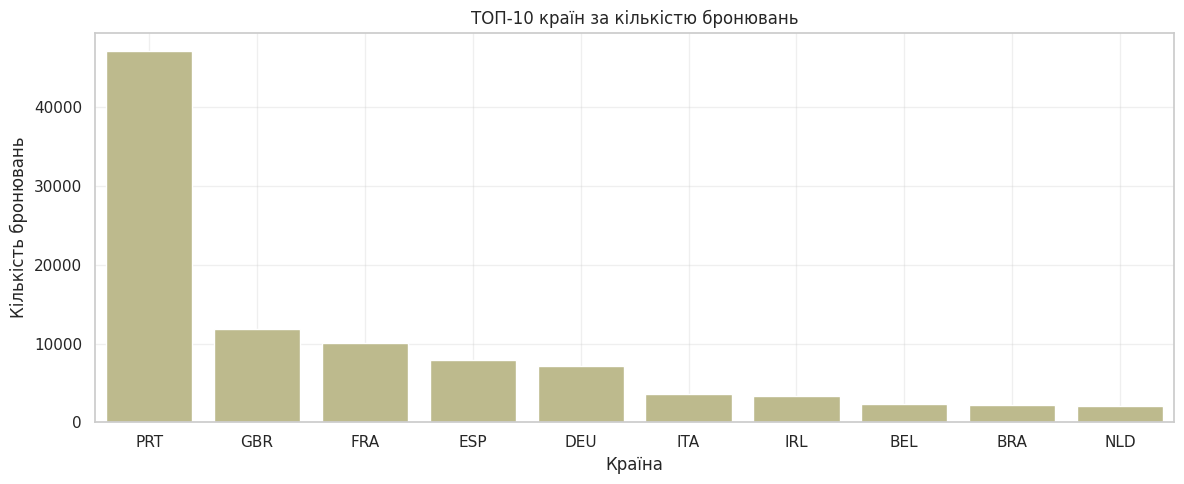

In [21]:
# Візуалізуємо ТОП-10 країн за кількістю бронювань

plt.figure(figsize=(12,5))

sns.barplot(
    x=nmb_customer_by_country.index,
    y=nmb_customer_by_country.values,
    color='#c5c185')

plt.title('ТОП-10 країн за кількістю бронювань')
plt.xlabel('Країна')
plt.ylabel('Кількість бронювань')
plt.grid(True, alpha=0.3)
plt.tight_layout();

Переважна більшість бронювань була здійснена клієнтами з Португалії. Кількість бронювань з цієї країни майже в 4 рази перевищує показник Великої Британії, яка посідає друге місце за кількістю клієнтів. Це свідчить про те, що основна частина попиту на послуги готелів формується внутрішнім ринком Португалії.

### **Дослідимо сезонність бронювання. Побудуємо лінійні графіки для кожного року, щоб визначити трендові місяці**

In [22]:
# Загрегуємо кількість бронювань помісячно
monthly_bookings = (
    df_clean.set_index('arrival_date').resample('MS').
    size().reset_index(name='bookings_count')
)

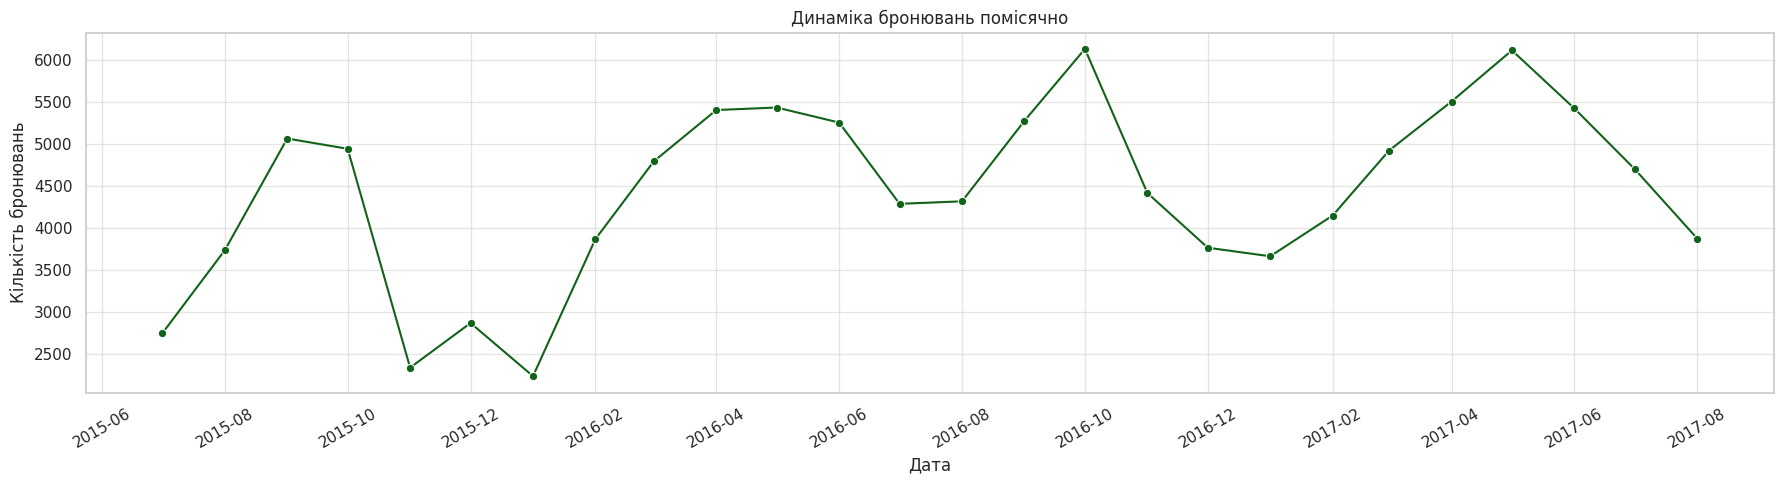

In [23]:
# Побудуємо наглядну візуалізацію
plt.figure(figsize=(18,5))

sns.lineplot(monthly_bookings,
             x='arrival_date',
             y='bookings_count',
             color='#106319',
             marker='o')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)

plt.title('Динаміка бронювань помісячно')
plt.xlabel('Дата')
plt.ylabel('Кількість бронювань')
plt.grid(True, alpha=0.5)
plt.tight_layout();

На графіку помітна виражена сезонність бронювань. Найвищі показники спостерігаються у жовтні 2016 року та травні 2017 року - понад ***6 тисяч бронювань***, що є максимальними значеннями за весь досліджуваний період.

Зростання кількості бронювань припадає на періоди з найбільш комфортними погодними умовами для відпочинку - весну та початок осені (*травень, вересень - жовтень)*. У холодні зимові місяці попит поступово знижується та досягає мінімальних значень.

Також, помітне зменшення кількості бронювань у період сильної літньої спеки (*липень - серпень*), що може свідчити про вплив кліматичних умов на поведінку клієнтів.

### **Проаналізуємо скасування бронювань. Який відсоток скасованих бронювань? Який тип клієнтів найчастіше скасовують бронювання?**

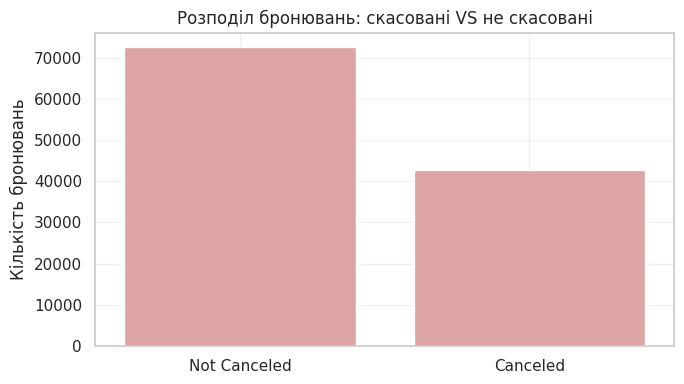

In [24]:
# Побудуємо візуалізацію розподілу бронювань
plt.figure(figsize=(7,4))

sns.countplot(data=df_clean,
              x='is_canceled',
              color = '#e59c99')

plt.xticks([0,1], ['Not Canceled', 'Canceled'])
plt.title('Розподіл бронювань: скасовані VS не скасовані')
plt.xlabel('')
plt.ylabel('Кількість бронювань')
plt.grid(True, alpha=0.3)
plt.tight_layout();

На всі бронювання припадає більше третини скасувань. Це доволі велика частка, яка може значно впливати на втрачений дохід та завантаженість готелю. Проаналізуємо детальніше, де ми маємо найбільші втрати.

In [25]:
# Подивимось на коефіцієнт скасувань у розрізі кожного місяця
cancel_rate_by_month = (
    df_clean.groupby('arrival_date_month')['is_canceled']
    .mean()
    .sort_values(ascending=False) * 100
).round(2)

display(cancel_rate_by_month)

,is_canceled
arrival_date_month,
June,41.43
April,40.81
May,39.50
September,39.24
October,38.08
August,37.78
July,37.38
December,35.28
February,33.47


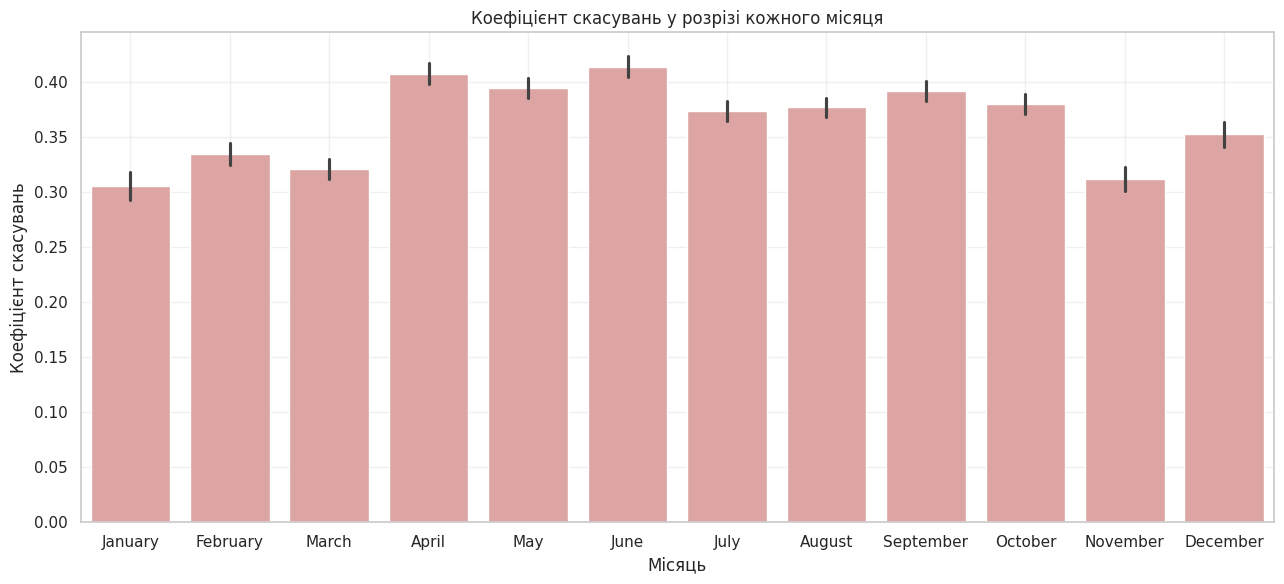

In [26]:
# Візуалізуємо коефіцієнт скасувань у розрізі кожного місяця
order_month = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

plt.figure(figsize=(13,6))

sns.barplot(
    data=df_clean,
    x='arrival_date_month',
    y='is_canceled',
    order=order_month,
    color='#e59c99'
)

plt.title('Коефіцієнт скаcувань у розрізі кожного місяця')
plt.xlabel('Місяць')
plt.ylabel('Коефіцієнт скасувань')
plt.grid(True, alpha=0.3)
plt.tight_layout();

Найвищий рівень скасувань спостерігається у червні та квітні (~40-41%).

Також, високі значення характерні для травня, вересня та жовтня (~38-39%).

Загалом різниця між місяцями не є критично великою, але весняно-літній період має дещо вищий ризик скасувань.


In [27]:
# Проаналізуємо, який тип клієнтів має найбільший cancellation rate.
# Зробимо аналіз у розрізі двох типів готелю

cr_by_customer = (
    df_clean.groupby(['hotel', 'customer_type'])
    ['is_canceled'].agg(['count', 'mean'])
)

cr_by_customer.style.background_gradient(cmap='YlOrRd')

Клієнти типу Transient - головне джерело скасувань. Цей сегмент є домінуючим за кількістю бронювань, але водночас має високий коефіцієнт скасувань:
- City Hotel - 57925 бронювань, *cancellation rate* **~46%**;
- Resort Hotel - 27930 бронювань, *cancellation rate* **~30%**.

 Найвищий *cancellation rate* мають клієнти типу Contract у City Hotel (~48%), але при цьому сегмент має значно меншу кількість бронювань - 2285. Тобто, клієнти цього типу хоч і демонструють найвищий коефіцієнт скасувань, але не створюють найбільше втрат.

In [28]:
# Проаналізуємо cancellation rate за типами депозиту
cr_by_deposit = (df_clean.groupby('deposit_type')['is_canceled']
                 .agg(['count', 'mean']))

cr_by_deposit.style.background_gradient(cmap='YlOrRd')

,count,mean
deposit_type,,
No Deposit,100478,0.280171
Non Refund,14553,0.993678
Refundable,160,0.212500


Більшість клієнтів обирали тип передплати - *'No Deposit'*, тобто, без передплати. Для цієї категорії *cancellation rate* становить **28%**  при понад **100К** бронювань.

Найбільш неочікуваний результат спостерігається для типу передплати *'Non Refund'*. Цей тип передбачає неповоротну передплату, тобто клієнт не має отримати кошти назад у разі скасування бронювання. Попри це, *cancellation rate* у цій категорії сягає **99%** у **14553** бронюваннях.

### **Дослідимо канали бронювання. Через який сегмент прийшло найбільше гостей?**

In [29]:
# Проаналізуємо дохід по сегментам ринку
revenue_by_market_segm = (
    df_revenue.groupby('market_segment')['total_price']
    .sum().sort_values(ascending=False)
)
display(revenue_by_market_segm)

,total_price
market_segment,
Online TA,12323109.38
Offline TA/TO,5565339.06
Direct,3317000.83
Groups,1831116.72
Corporate,575993.19
Aviation,70868.36
Complementary,4806.53


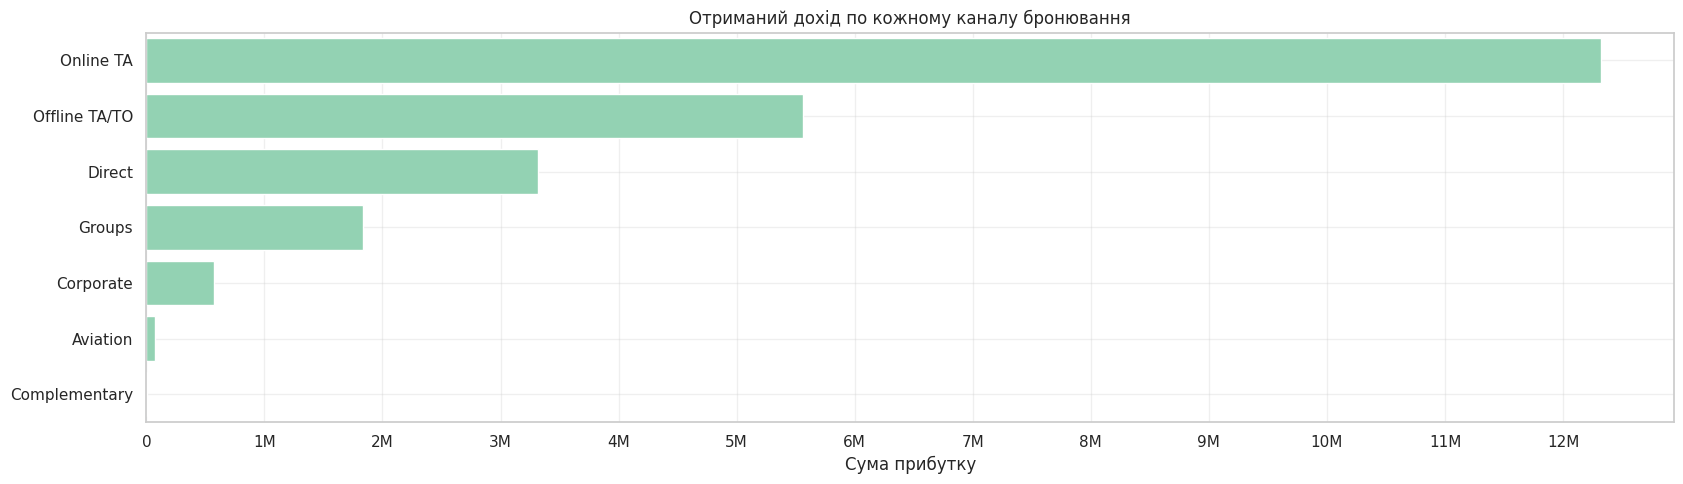

In [30]:
# Візуалізуємо дохід по сегментам ринку
plt.figure(figsize=(17,5))

ax = sns.barplot(
    x=revenue_by_market_segm.values,
    y=revenue_by_market_segm.index,
    color='#89dcb3'
)

def human_format(x, pos):
    if x >= 1000000:
        return f'{x/1000000:.0f}M'
    elif x >= 1000:
        return f'{x/100:.0f}K'
    return f'{x:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_format))
ax.xaxis.set_major_locator(ticker.MaxNLocator(15))

plt.title('Отриманий дохід по кожному каналу бронювання')
plt.xlabel('Сума прибутку')
plt.ylabel('')
plt.grid(True, alpha=0.3)
plt.tight_layout();

Бронювання через сегмент *Online TA* (бронювання через онлайн платформи) принесли найбільший дохід - понад **12 млн**. Це основний канал залучення клієнтів, що свідчить про високу залежність готелів від OTA-платформ (наприклад, Booking, Expedia).

Через сегмент *Offline TA/TO* (турагенції та туроператори) було отримано близько **5.5 млн** доходу. Це робить його другим за значенням каналом.

Сегмент *Direct* (прямі бронювання) приніс **~3.3 млн**, що є важливим показником ефективності прямого продажу без посередників.

*Groups* (групові бронювання) запезпечили **~1.8 млн** доходу.

Сегмент *Corporate* (корпоративні клієнти) приніс понад **575 тис** доходу.

Майже **71тис** доходу приніс сегмент *Aviation*. Зазвичай, такі бронювання здійснюються через затримку/скасування рейсів для екіпажів літаків, пілотів, стюардес або пасажирів.

Сегмент *Complementary* (безкоштовні бронювання) дав мінімальний дохід **~5 тис**. Що цілком нормально, так як ці номери зазвичай надаються як подарунок: VIP-гостям, партнерам, для компенсації або у межах промо-акцій.

In [31]:
# Обчислимо кількість бронювань та cancellation rate по кожному маркет сегменту
cr_by_market_segm = (
    df_clean.groupby('market_segment')['is_canceled']
    .agg(['count', 'mean'])
    .sort_values(by='count', ascending=False)
)
cr_by_market_segm.style.background_gradient(cmap='YlOrRd')

,count,mean
market_segment,,
Online TA,53529,0.362999
Offline TA/TO,24071,0.344024
Groups,19691,0.612259
Direct,11664,0.149777
Corporate,5275,0.187488
Complementary,724,0.121547
Aviation,235,0.221277
Undefined,2,1.000000


Найбільша кількість бронювань надходить через сегмент *Online TA* (53529), що є очікуваним, так як онлайн турагенції зазвичай є основним каналом залучення клієнтів, а *cancellation rate*  становить **36%**, що є середнім показником.

Другим за обсягом є сегмент *Offline TA/TO* (24071) з *cancellation rate* - **34%**. Це свідчить про схожу поведінку клієнтів, незалежно від типу туристичної агенції (онлайн чи офлайн).

Особливо виділяється сегмент *Groups*, який має значно вищий *cancellation rate* -  **61%**. Це вказує на те, що клієнти цього сегменту дуже схильні до скасування бронювань.

Натомість, сегменти *Direct* (**15%**) та *Corporate* (**18%**) мають найнижчі показники скасувань, що може свідчити про більш стабільні та надійні канали бронювання.

### **Проаналізуємо типи клієнтів. Хто приносить найбільший дохід, а хто бронює завчасно?**

In [32]:
# Проаналізуємо, який дохід нам приніс кожний тип клієнта
revenue_by_customer = (
    df_revenue.groupby('customer_type')['total_price']
    .sum().sort_values(ascending=False)
)
display(revenue_by_customer)

,total_price
customer_type,
Transient,17278604.64
Transient-Party,4814519.66
Contract,1475741.91
Group,119367.86


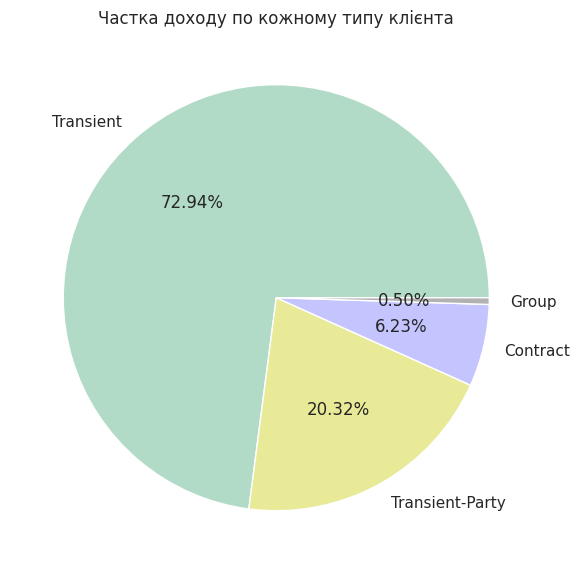

In [33]:
# Візуалізуємо частку доходу по кожному типу клієнта
colors = ['#b1dbc6', '#e8ea97', '#c4c4ff', '#b2b2b2']

revenue_by_customer.plot.pie(
   figsize=(6,6),
   colors=colors,
   autopct = '%1.2f%%',
   ylabel='',
   title='Частка доходу по кожному типу клієнта'
)
plt.tight_layout();

Як і очікувалось, *Transient* - це тип клієнтів, які принесли найбільший дохід понад **17 млн**.

Клієнти типу *Transient-Party* - це не офіційна група, кілька людей подорожують разом. Займають почесне друге місце за сумою прибутку **~4.8 млн**.

*Contract* - це клієнти за контрактом, тобто між готелем і компанією є договір. Завдяки контрактним клієнтам було отримано **~1.48 млн** доходу.

*Group* - групові клієнти, які принесли **119 тис** прибутку, що становить лише 0,5% від загальної виручки готелів.

Таким чином, основним джерелом доходу для готелів є клієнти типу ***Transient***, які забезпечують майже три чверті всієї виручки. Це свідчить про високу залежність бізнесу від індивідуальних бронювань.

In [34]:
# Який середній час від дня бронювання до дня заселення по кожному клієнту?
avg_lead_time_customer = (
    df_clean.groupby('customer_type')['lead_time']
    .mean().sort_values(ascending=False)
)
display(avg_lead_time_customer)

,lead_time
customer_type,
Contract,143.494454
Transient-Party,138.070432
Transient,94.091992
Group,56.137500


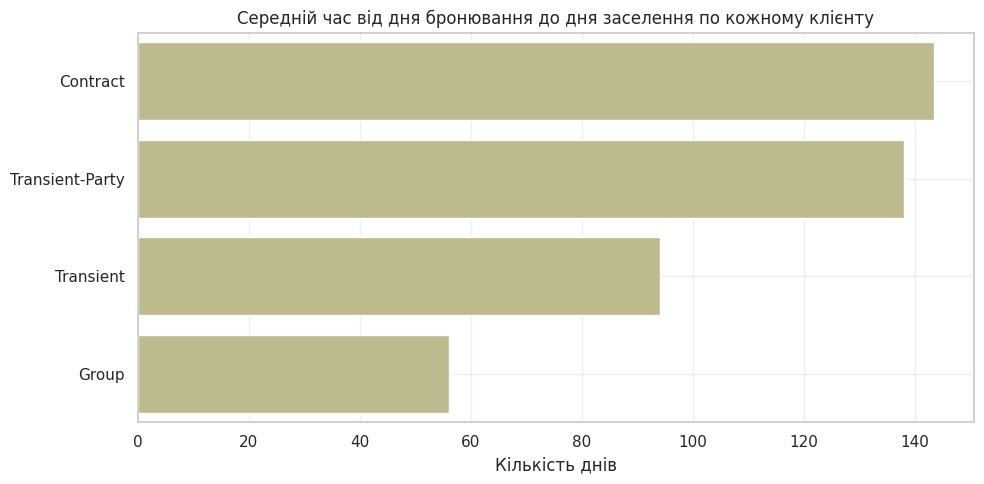

In [35]:
# Візуалізуємо середній lead_time по кожному типу клієнта
plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_lead_time_customer.values,
    y=avg_lead_time_customer.index,
    color='#c5c185'
)

plt.title('Cередній час від дня бронювання до дня заселення по кожному клієнту')
plt.xlabel('Кількість днів')
plt.ylabel('')
plt.grid(True, alpha=0.3)
plt.tight_layout();

Клієнти типу *Contract* надають перевагу ранньому бронюванню і в середньому їх lead time становить близько **143 днів**.

*Transient-Party* клієнти мають дещо нижчий lead time **~138 днів**.

Для клієнтів типу *Transient* середній час від бронювання до заселення становить приблизно **94 дні**, або близько трьох місяців .

Найнижчий середній lead time спостерігається у клієнтів типу *Group* - **56 днів**. Ймовірно, групові поїздки плануються та підтверджуються в коротші терміни, ніж індивідуальні або контрактні бронювання.

In [36]:
# Проаналізуємо тип клієнта VS тип депозиту
customer_deposit_type = (
    df_clean.groupby(['customer_type', 'deposit_type'])
    .size().unstack(fill_value=0)
)

customer_deposit_type.style.background_gradient(axis=None, cmap='YlOrRd')

deposit_type,No Deposit,Non Refund,Refundable
customer_type,,,
Contract,3511,544,2
Group,552,0,8
Transient,72961,12876,18
Transient-Party,23454,1133,132


Бачимо, що клієнти всіх типів переважно обирали **No Deposit**, тобто бронювання без передплати, де оплата відбувається при заселенні.

**Refundable**, тобто поворотний депозит, клієнт може отримати гроші назад при скасуванні за правилами готелю. Зазвичай, це можливо не пізніше ніж за 7 днів до дати заселення. Такий тип депозиту клієнти обирали вкрай рідко.

І третій тип депозиту - **Non Refund**. Неповоротний депозит, у разі скасування клієнт не отримував кошти назад. Очікувалось, що саме цей тип депозиту обере найменша кількість гостей. Але, за частотою вибору, він є другим, якщо не брати до уваги групові бронювання, цей тип клієнтів взагалі не обирава даний тип депозиту.

### **Проаналізуємо тривалість перебування гостей у готелі**

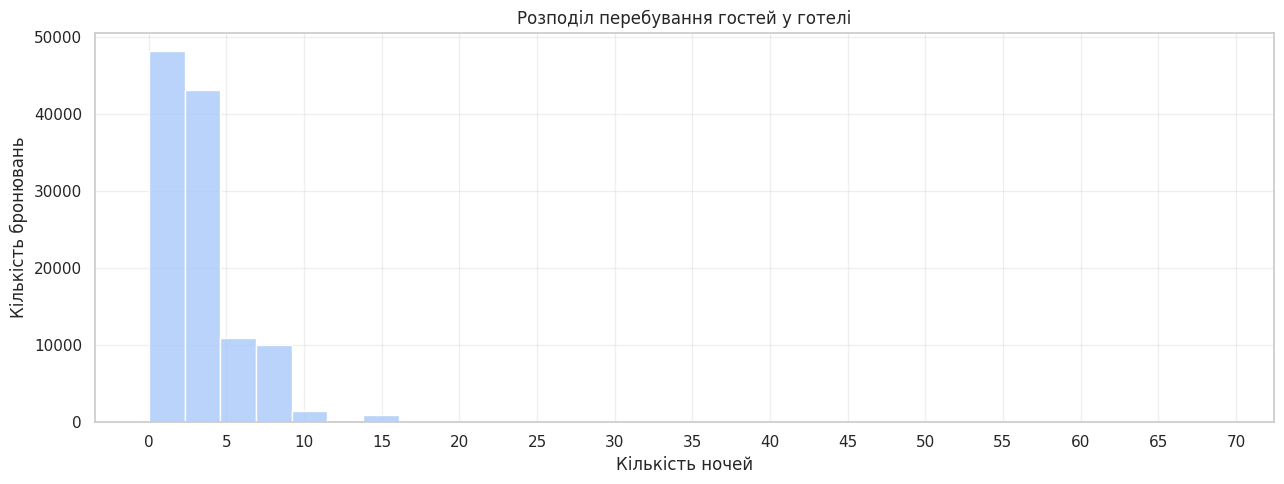

In [37]:
# Побудуємо гістограму розподілу total_nights
plt.figure(figsize=(13,5))

ax = sns.histplot(
    df_clean['total_nights'],
    bins=30,
    color='#a2c5f9'
)

ax.xaxis.set_major_locator(ticker.MaxNLocator(16))

plt.title('Розподіл перебування гостей у готелі')
plt.xlabel('Кількість ночей')
plt.ylabel('Кількість бронювань')
plt.grid(True, alpha=0.3)
plt.tight_layout();


З графіка видно, що переважна більшість гостей зупинялися в готелях на **1-5 ночей**. Саме на цей діапазон припадає близько *90 тисяч* бронювань, що свідчить про переважання короткострокових поїздок.

Також, спостерігається значна кількість бронювань на **5-10 ночей** - понад *20 тисяч*. Проте зі збільшенням тривалості перебування кількість таких бронювань стрімко зменшується.

Бронювання на **15 і більше ночей** зустрічаються досить рідко та формують довгий правий хвіст розподілу. Це свідчить про наявність невеликої кількості гостей, які обирали тривале проживання.

In [38]:
# Проаналізуємо середню тривалість перебування по місяцях
avg_monthly_stay = (
    df_clean.groupby('arrival_date_month')['total_nights'].
    mean().sort_values(ascending=False)
)

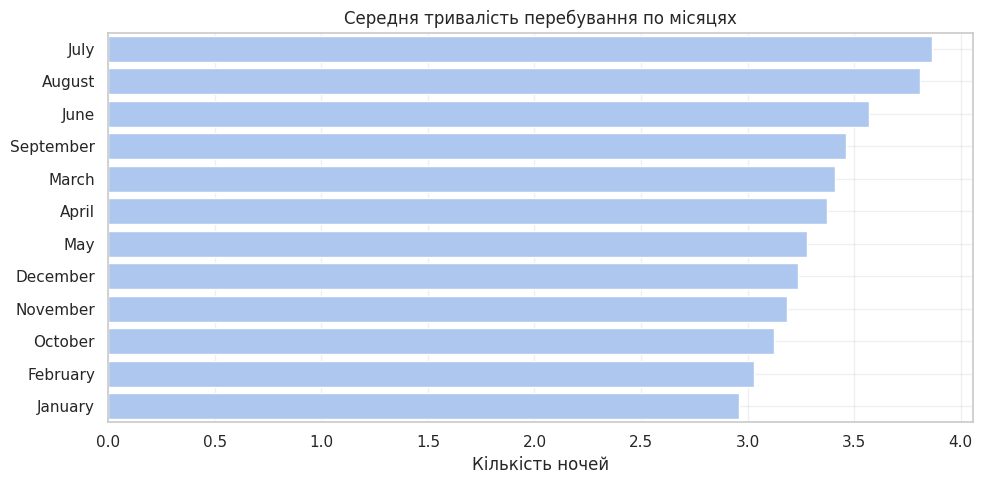

In [39]:
# Побудуємо наглядну візуалізацію
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=avg_monthly_stay.values,
    y=avg_monthly_stay.index,
    color='#a2c5f9'
)
plt.title('Середня тривалість перебування по місяцях')
plt.xlabel('Кількість ночей')
plt.ylabel('')
plt.grid(True, alpha=0.3)
plt.tight_layout();

*Липень та серпень* характеризуються найдовшою середньою тривалістю перебування гостей, тоді *як січень та лютий* — найкоротшою. Проте сезонні відмінності є незначними: в середньому гості проживали в готелях **від 3 до 4 ночей** незалежно від місяця прибуття.

### **Проаналізуємо lead time. За скільки днів до прибуття гості бронюють номери?**

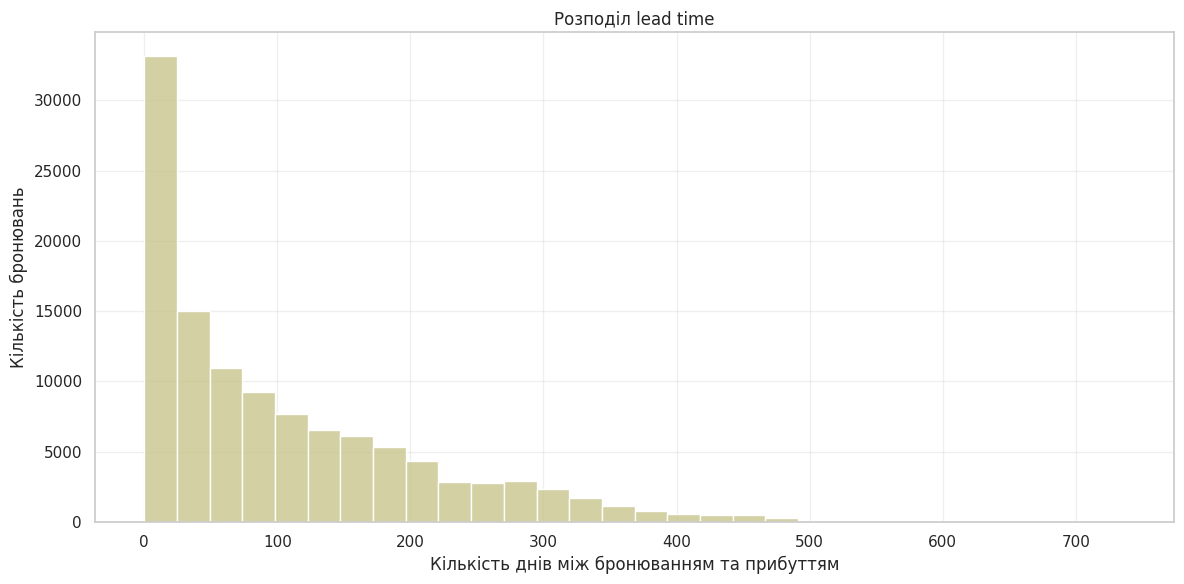

In [40]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df_clean.lead_time,
    bins=30,
    color='#c5c185'
)

plt.title('Розподіл lead time')
plt.xlabel('Кількість днів між бронюванням та прибуттям')
plt.ylabel('Кількість бронювань')

plt.grid(True, alpha=0.3)
plt.tight_layout();

На графіку можна побачити, що більшість гостей здійснюють бронювання протягом першого місяця до заселення. Чим більший проміжок часу між бронюванням та прибуттям, тим менше таких бронювань спостерігається.

### **Перевірка статистичної гіпотези**

Перевіримо, чи є середній *lead time* статистично вищим для скасованих бронювань.

Нагадаю, що *lead time* - це кількість днів між датою бронювання та датою заселення.

**Гіпотези**   

$H_0: \mu_{canceled} = \mu_{not_-canceled}$ - середній lead time однаковий для обох груп;

$H_1: \mu_{canceled} > \mu_{not_-canceled}$ - скасовані бронювання мають вищий середній lead time.

Тип тесту: правосторонній (one-tailed).

In [41]:
# Формуємо вибірки
lead_not_canceled = df_clean[df_clean.is_canceled == 0]['lead_time']
lead_canceled = df_clean[df_clean.is_canceled == 1]['lead_time']

In [42]:
# Встановимо рівень значущості
alpha = 0.05

In [43]:
# Виконуємо правосторонній z-тест
from statsmodels.stats import weightstats as stests

z_stat_sm, p_val_sm = stests.ztest(lead_canceled,
                                  lead_not_canceled,
                                  alternative='larger')
print('Результати z-тесту:')
print(f'z-статистика = {z_stat_sm:.3f}')
print(f'p-value = {p_val_sm:.8f}')

Результати z-тесту:
z-статистика = 105.338
p-value = 0.00000000


In [44]:
# Інтерпретація результатів
if p_val_sm < alpha:
  print(f'p-value = {p_val_sm:.8f} < α = {alpha} -> На рівні значущості α відхиляємо гіпотезу H₀.')
  print('Є статистично значущі докази, що lead time у скасованих бронюваннях вищий, ніж у не скасованих.')
else:
  print(f'p-value = {p_val_sm:.8f} ≥ α = {alpha} -> Не відхиляємо гіпотезу H₀.')
  print('Не маємо достатньо підстав вважати, що середній lead time однаковий для обох груп')

p-value = 0.00000000 < α = 0.05 -> На рівні значущості α відхиляємо гіпотезу H₀.
Є статистично значущі докази, що lead time у скасованих бронюваннях вищий, ніж у не скасованих.


Так як маємо великий набір даних, доцільно буде також обчислити розмір ефекту.

In [45]:
# Обчислимо коефіцієнт d за Коеном
mean1 = lead_canceled.mean()
mean2 = lead_not_canceled.mean()

std1 = lead_canceled.std(ddof=1)
std2 = lead_not_canceled.std(ddof=1)

n1 = len(lead_canceled)
n2 = len(lead_not_canceled)

pooled_std = np.sqrt(
    ((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2)
)
cohens_d = (mean1 - mean2) / pooled_std

print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = 0.643


Було проведено односторонній z-тест для перевірки гіпотези про те, що середній lead time скасованих бронювань вищий за середній lead time нескасованих бронювань.

Результати тесту показали статистично значущу різницю між групами (z-статистика = 105.338, p-value < $10^{-8}$). Таким чином, нульову гіпотезу було відхилено. Це свідчить про те, що бронювання, зроблені заздалегідь, мають вищу схильність до скасування.

Для оцінки практичної значущості різниці було розраховано Cohen's d. Значення 0.643 свідчить про ефект середньої сили, близький до великого. Це означає, що відмінність у lead time між скасованими та нескасованими бронюваннями є не лише статистично значущою, а й достатньо суттєвою з практичної точки зору.

---



### **Рекомендації для бізнесу**

1. Португалія є основним ринком для готелів. Саме ця країна забезпечує найбільшу кількість бронювань та найбільшу частку доходу.

   ***Рекомендація***:
   - підтримувати присутність на португальському ринку, але паралельно шукати шляхи збільшення клієнтської бази з інших країн.

2. Маємо виражену сезонність попиту. Пікова кількість бронювання припадає на травень, вересень та жовтень, тоді як у липні та серпені спостерігається спад.

   ***Рекомендація***:

   - оптимізувати ціни залежно від сезону;
   - розробити 'спеціальні пропозиції' в сезон низького попиту, для заохочення бронювань.

3. Середній коефіцієнт скасування бронювань становить - 37%. Пікові значення припадають на квітень та червень ~41%. Найстабільнішим місяцем є січень ~30%.

   ***Рекомендація***:

   - протестувати тимчасове впровадження тільки 'суворіших' типів депозиту -  Refundable та Non Refund на місяці підвищеного ризику скасувань;

   - у найстабільніші місяці можна тестувати нові маркетингові стратегії, так як ризик скасувань нижчий.

4. Transient - це основний сегмент клієнтів готелю. Вони є ключовим джерелом доходу, але водночас мають найвищий коефіцієнт скасувань. Також, клієнти цього типу надають перевагу No Deposit та роблять бронювання в середньому впродовж трьох місяців до заселення.

   ***Рекомендація***:

   - запровадити знижки при виборі типу передплати Refundable або Non Refund;

   - працювати з довгим lead time, наприклад, запускати автоматичну e-mail розсилку з нагадуваннями, для зниження ризику скасувань;
   
   - запровадження бонусів. Наприклад, за раннє підтвердження бронювання (це можуть бути покращені умови номера або вечеря у подарунок).

5. Онлайн платформи є основним каналом залучення клієнтів, як за кількістю бронювань, так і за доходом.

   ***Рекомендація***:

   - розширювати співпрацю з ОТА (booking, airnbnb, expedia);

   -  удосконалювати дизайн власного сайту. Можливо зробити дизайн схожий до букінг платформ. Адже, схоже, що гостям до душі такий варіант бронювання, де необхідний мінімальним контактом з персоналом;
   
   - розвивати інші канали бронювання, щоб зменшити взаємодію з посередниками.

6. Середня тривалість перебування варьюється від 3 до 4 ночей. Влітку трохи довша, а взимку коротша.

   ***Рекомендація***:

   - створити 'спеціальні пакети' для заохочення довшого перебування в низький сезон (наприклад, '3 + 1' -> четверта ніч безкоштовно або 3 години спа у подарунок).